# Customer Segmentation — Phase 3 & 4: PCA Visualisation + Business Personas
Mall Customers Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
CLUSTER_COLORS = ["#4C72B0", "#E07070", "#2ca02c", "#FF7F0E", "#9467BD"]
 

In [2]:
# LOAD DATA

 
df = pd.read_csv("customers_clustered.csv")
 
# Ensure correct types
df["Cluster"] = df["Cluster"].astype(int)
N_CLUSTERS    = df["Cluster"].nunique()
 
print("=" * 60)
print("PHASE 3 & 4 — PCA + BUSINESS PERSONAS")
print("=" * 60)
print(f"Customers   : {len(df)}")
print(f"Clusters    : {N_CLUSTERS}")
print(f"Cluster sizes:\n{df['Cluster'].value_counts().sort_index().to_string()}")

PHASE 3 & 4 — PCA + BUSINESS PERSONAS
Customers   : 200
Clusters    : 5
Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23


In [3]:
# PROFILE CLUSTERS

profile = df.groupby("Cluster").agg(
    Count       =("CustomerID", "count"),
    AvgAge      =("Age", "mean"),
    AvgIncome   =("AnnualIncome", "mean"),
    AvgSpending =("SpendingScore", "mean"),
    PctFemale   =("Gender", lambda x: (x == "Female").mean() * 100),
).round(1)
 
print(f"\nCluster profiles:")
print(profile.to_string())


Cluster profiles:
         Count  AvgAge  AvgIncome  AvgSpending  PctFemale
Cluster                                                  
0           81    42.7       55.3         49.5       59.3
1           39    32.7       86.5         82.1       53.8
2           22    25.3       25.7         79.4       59.1
3           35    41.1       88.2         17.1       45.7
4           23    45.2       26.3         20.9       60.9


In [4]:
# ── Auto-assign persona names from centroid positions 
# Logic: rank clusters by income and spending score to assign meaningful names

def assign_persona(row):
    inc = row["AvgIncome"]
    spd = row["AvgSpending"]
    inc_med = profile["AvgIncome"].median()
    spd_med = profile["AvgSpending"].median()
 
    if inc >= inc_med and spd >= spd_med:
        return "High Value"
    elif inc >= inc_med and spd < spd_med:
        return "Careful Spenders"
    elif inc < inc_med and spd >= spd_med:
        return "Impulsive Buyers"
    elif inc < inc_med and spd < spd_med:
        return "Budget Conscious"
    else:
        return "Mid-Tier"
 
profile["Persona"] = profile.apply(assign_persona, axis=1)

In [8]:
# Mid-tier catch: if the above leaves any cluster without a unique name,
# assign it to the cluster closest to the overall centroid
assigned = profile["Persona"].tolist()
if len(set(assigned)) < N_CLUSTERS:
    overall_inc = df["AnnualIncome"].mean()
    overall_spd = df["SpendingScore"].mean()
    for idx in profile.index:
        dist = np.sqrt((profile.loc[idx,"AvgIncome"] - overall_inc)**2 +
                       (profile.loc[idx,"AvgSpending"] - overall_spd)**2)
        profile.loc[idx, "DistToCenter"] = dist
    mid_idx = profile["DistToCenter"].idxmin()
    profile.loc[mid_idx, "Persona"] = "Mid-Tier"
 
# Map persona back to main dataframe
df["Persona"] = df["Cluster"].map(profile["Persona"])
 
print(f"\nPersona assignments:")
print(profile[["Count","AvgAge","AvgIncome","AvgSpending","PctFemale","Persona"]].to_string())


Persona assignments:
         Count  AvgAge  AvgIncome  AvgSpending  PctFemale           Persona
Cluster                                                                    
0           81    42.7       55.3         49.5       59.3      ⚖️  Mid-Tier
1           39    32.7       86.5         82.1       53.8        High Value
2           22    25.3       25.7         79.4       59.1  Impulsive Buyers
3           35    41.1       88.2         17.1       45.7  Careful Spenders
4           23    45.2       26.3         20.9       60.9  Budget Conscious


# 3. PCA VISUALISATION


PCA explained variance:
  PC1 : 44.3%
  PC2 : 33.3%
  Total: 77.6% of variance retained in 2D


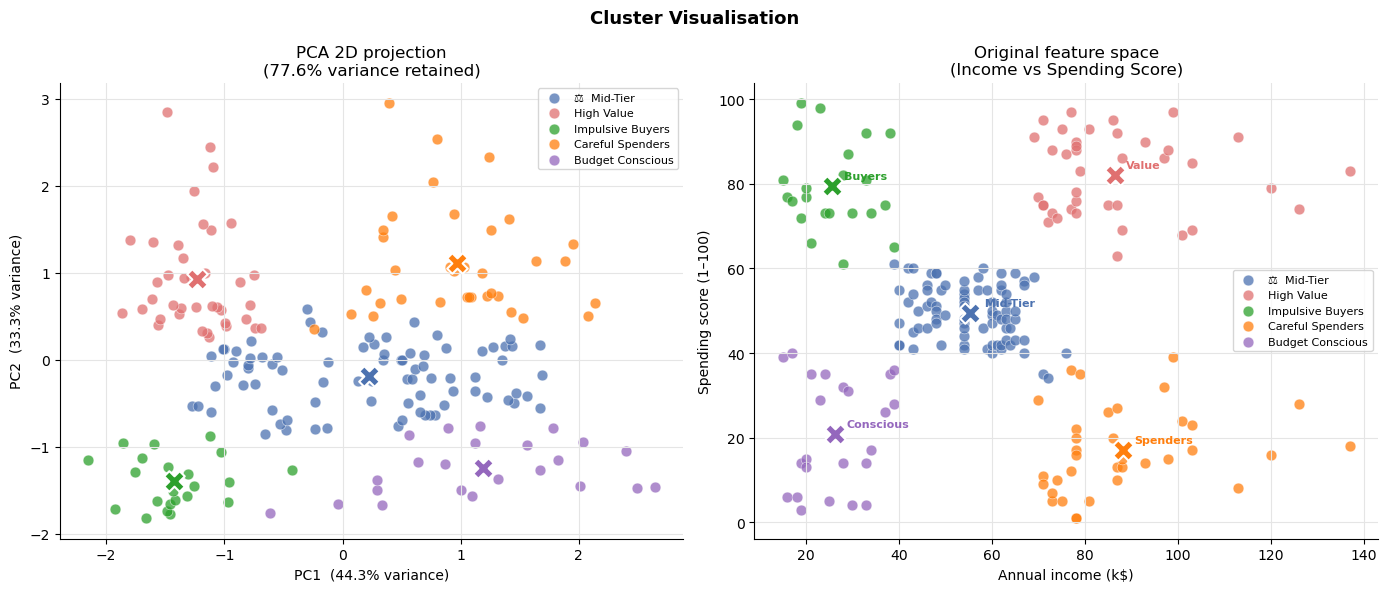

In [9]:
features    = ["Age", "AnnualIncome", "SpendingScore"]
X_scaled    = StandardScaler().fit_transform(df[features])
pca         = PCA(n_components=2)
X_pca       = pca.fit_transform(X_scaled)
var_ratio   = pca.explained_variance_ratio_
 
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
 
print(f"\nPCA explained variance:")
print(f"  PC1 : {var_ratio[0]*100:.1f}%")
print(f"  PC2 : {var_ratio[1]*100:.1f}%")
print(f"  Total: {sum(var_ratio)*100:.1f}% of variance retained in 2D")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Cluster Visualisation", fontweight="bold", fontsize=13)
 
# Panel 1: PCA 2D scatter
ax = axes[0]
for cid in range(N_CLUSTERS):
    mask   = df["Cluster"] == cid
    color  = CLUSTER_COLORS[cid]
    label  = profile.loc[cid, "Persona"]
    ax.scatter(df.loc[mask, "PC1"], df.loc[mask, "PC2"],
               s=60, color=color, alpha=0.75,
               edgecolors="white", linewidth=0.4, label=label)
 
# PCA centroids
for cid in range(N_CLUSTERS):
    cx = df.loc[df["Cluster"] == cid, "PC1"].mean()
    cy = df.loc[df["Cluster"] == cid, "PC2"].mean()
    ax.scatter(cx, cy, s=220, color=CLUSTER_COLORS[cid],
               marker="X", edgecolors="white", linewidth=1.5, zorder=5)
 
ax.set_xlabel(f"PC1  ({var_ratio[0]*100:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PC2  ({var_ratio[1]*100:.1f}% variance)", fontsize=10)
ax.set_title(f"PCA 2D projection\n({sum(var_ratio)*100:.1f}% variance retained)")
ax.legend(fontsize=8, loc="best")
 
# Panel 2: Original feature space — Income vs Spending Score
ax2 = axes[1]
for cid in range(N_CLUSTERS):
    mask   = df["Cluster"] == cid
    color  = CLUSTER_COLORS[cid]
    label  = profile.loc[cid, "Persona"]
    ax2.scatter(df.loc[mask, "AnnualIncome"], df.loc[mask, "SpendingScore"],
                s=60, color=color, alpha=0.75,
                edgecolors="white", linewidth=0.4, label=label)
 
# Centroids in original space
for cid in range(N_CLUSTERS):
    cx = profile.loc[cid, "AvgIncome"]
    cy = profile.loc[cid, "AvgSpending"]
    ax2.scatter(cx, cy, s=220, color=CLUSTER_COLORS[cid],
                marker="X", edgecolors="white", linewidth=1.5, zorder=5)
    ax2.annotate(profile.loc[cid, "Persona"].split(" ", 1)[-1],
                 (cx, cy), textcoords="offset points", xytext=(8, 5),
                 fontsize=8, color=CLUSTER_COLORS[cid], fontweight="bold")
 
ax2.set_xlabel("Annual income (k$)", fontsize=10)
ax2.set_ylabel("Spending score (1–100)", fontsize=10)
ax2.set_title("Original feature space\n(Income vs Spending Score)")
ax2.legend(fontsize=8, loc="best")
 
plt.tight_layout()
plt.savefig("phase3_cluster_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()

# BAR CHARTS — MEAN FEATURES PER CLUSTER

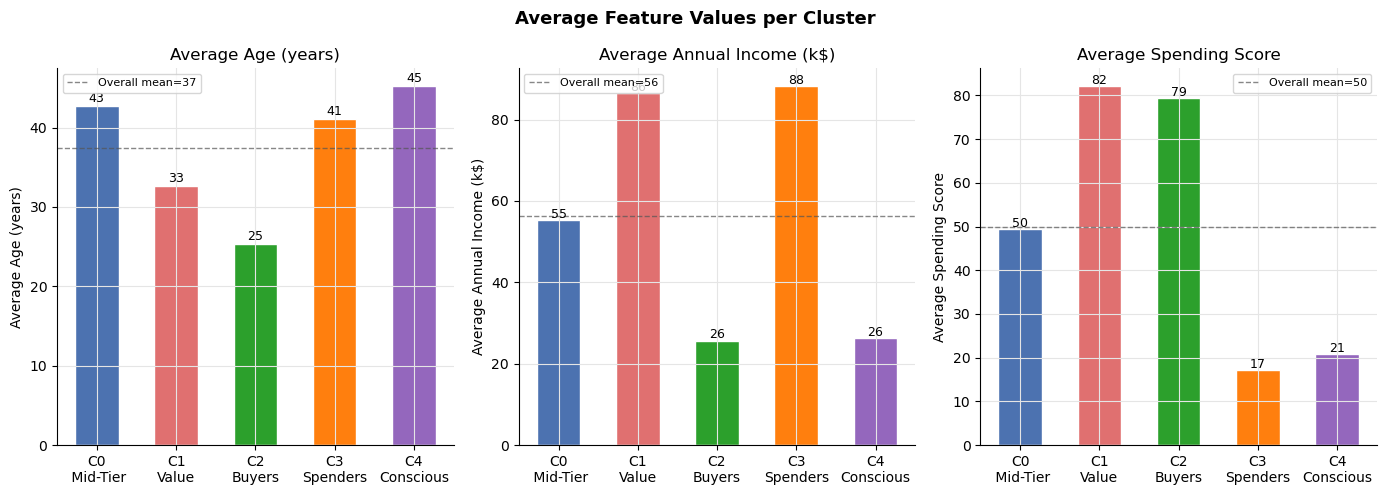

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Average Feature Values per Cluster", fontweight="bold", fontsize=13)
 
feat_meta = [
    ("AvgAge",      "Average Age (years)",       "#4C72B0"),
    ("AvgIncome",   "Average Annual Income (k$)", "#2ca02c"),
    ("AvgSpending", "Average Spending Score",     "#E07070"),
]
 
for ax, (feat, label, color) in zip(axes, feat_meta):
    vals   = profile[feat].values
    labels = [f"C{i}\n{profile.loc[i,'Persona'].split(' ',1)[-1]}"
              for i in profile.index]
    colors = [CLUSTER_COLORS[i] for i in profile.index]
    bars   = ax.bar(labels, vals, color=colors, width=0.55, edgecolor="white")
    # Mean line
    ax.axhline(profile[feat].mean(), color="#555", linestyle="--",
               linewidth=1, alpha=0.7, label=f"Overall mean={profile[feat].mean():.0f}")
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.0f}", ha="center", fontsize=9)
 
plt.tight_layout()
plt.savefig("phase4_cluster_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()

# RADAR CHART — MULTI-DIMENSIONAL PERSONA COMPARISON

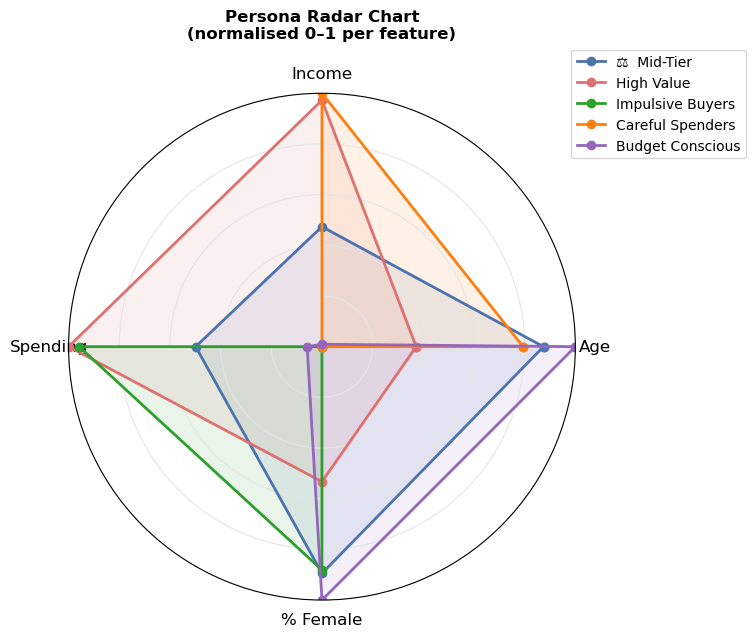

In [11]:
# Normalise to 0–1 for radar plot comparability
radar_feats = ["AvgAge", "AvgIncome", "AvgSpending", "PctFemale"]
radar_labels = ["Age", "Income", "Spending", "% Female"]
 
radar_data = profile[radar_feats].copy()
for col in radar_feats:
    mn, mx = radar_data[col].min(), radar_data[col].max()
    radar_data[col] = (radar_data[col] - mn) / (mx - mn + 1e-9)
 
N_VARS = len(radar_feats)
angles = np.linspace(0, 2 * np.pi, N_VARS, endpoint=False).tolist()
angles += angles[:1]   # close the polygon
 
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
ax.set_facecolor("white")
 
for cid in profile.index:
    vals   = radar_data.loc[cid, radar_feats].tolist()
    vals  += vals[:1]
    color  = CLUSTER_COLORS[cid]
    label  = profile.loc[cid, "Persona"]
    ax.plot(angles, vals, "o-", linewidth=2, color=color, label=label)
    ax.fill(angles, vals, alpha=0.10, color=color)
 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=12)
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.set_title("Persona Radar Chart\n(normalised 0–1 per feature)",
             fontweight="bold", fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(color="#e5e5e5", linewidth=0.8)
 
plt.tight_layout()
plt.savefig("phase4_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
 

 # BUSINESS RECOMMENDATIONS PER PERSONA


BUSINESS RECOMMENDATIONS BY PERSONA

  ⚖️  Mid-Tier  (n=81)  [Priority: MEDIUM]
    Strategy : Cross-selling, upgrade nudges, mid-range promotions
    Channel  : Email newsletters, in-app recommendations
    Watch out: Largest segment — generic messaging risks being ignored


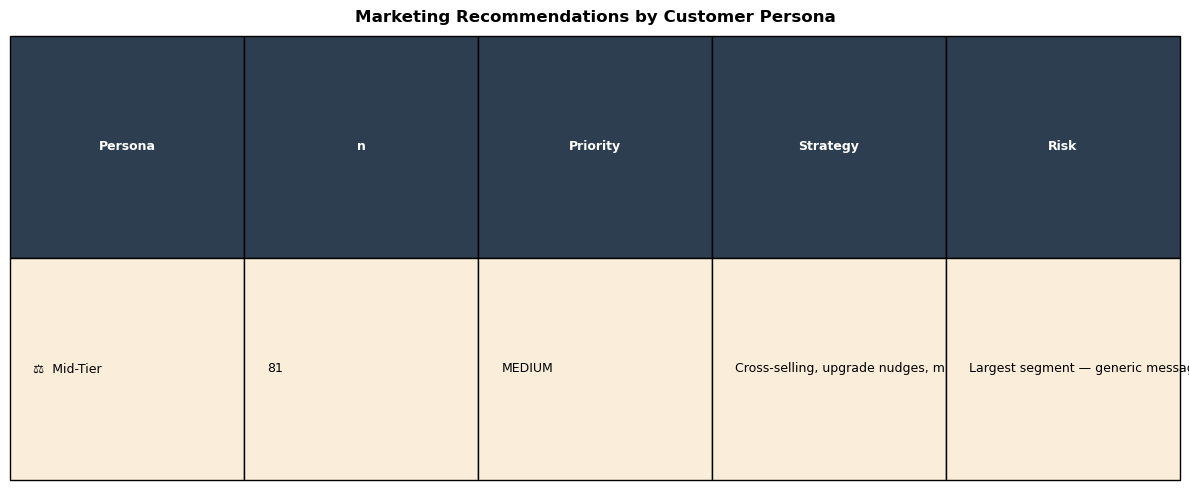

In [12]:
recommendations = {
    "💎 High Value": {
        "size"    : int(profile.loc[profile["Persona"]=="💎 High Value", "Count"].values[0])
                    if "💎 High Value" in profile["Persona"].values else "—",
        "strategy": "Loyalty programmes, early access to new products, VIP memberships",
        "channel" : "Personalised email, concierge service",
        "risk"    : "Churn to competitors — prioritise retention",
        "priority": "HIGH",
    },
    "💰 Careful Spenders": {
        "size"    : int(profile.loc[profile["Persona"]=="💰 Careful Spenders", "Count"].values[0])
                    if "💰 Careful Spenders" in profile["Persona"].values else "—",
        "strategy": "Premium value communication, ROI-focused messaging, quality guarantees",
        "channel" : "Email with detailed product info, comparison guides",
        "risk"    : "Under-monetised — high potential if trust is established",
        "priority": "HIGH",
    },
    "🛍️ Impulsive Buyers": {
        "size"    : int(profile.loc[profile["Persona"]=="🛍️ Impulsive Buyers", "Count"].values[0])
                    if "🛍️ Impulsive Buyers" in profile["Persona"].values else "—",
        "strategy": "Flash sales, time-limited discounts, bundle offers",
        "channel" : "Push notifications, social media ads",
        "risk"    : "Discount dependency — avoid training them to wait for sales",
        "priority": "MEDIUM",
    },
    "📦 Budget Conscious": {
        "size"    : int(profile.loc[profile["Persona"]=="📦 Budget Conscious", "Count"].values[0])
                    if "📦 Budget Conscious" in profile["Persona"].values else "—",
        "strategy": "Entry-level products, instalment payment options, basic loyalty points",
        "channel" : "SMS, low-cost digital channels",
        "risk"    : "Low margin — focus on volume and retention",
        "priority": "LOW",
    },
    "⚖️  Mid-Tier": {
        "size"    : int(profile.loc[profile["Persona"]=="⚖️  Mid-Tier", "Count"].values[0])
                    if "⚖️  Mid-Tier" in profile["Persona"].values else "—",
        "strategy": "Cross-selling, upgrade nudges, mid-range promotions",
        "channel" : "Email newsletters, in-app recommendations",
        "risk"    : "Largest segment — generic messaging risks being ignored",
        "priority": "MEDIUM",
    },
}
 
print("\n" + "=" * 65)
print("BUSINESS RECOMMENDATIONS BY PERSONA")
print("=" * 65)
for persona, rec in recommendations.items():
    if rec["size"] == "—":
        continue
    print(f"\n  {persona}  (n={rec['size']})  [Priority: {rec['priority']}]")
    print(f"    Strategy : {rec['strategy']}")
    print(f"    Channel  : {rec['channel']}")
    print(f"    Watch out: {rec['risk']}")
 
# Recommendations summary chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")
ax.set_facecolor("white")
 
col_labels = ["Persona", "n", "Priority", "Strategy", "Risk"]
row_data   = []
for persona, rec in recommendations.items():
    if rec["size"] == "—":
        continue
    row_data.append([persona, str(rec["size"]), rec["priority"],
                     rec["strategy"][:55] + "…" if len(rec["strategy"]) > 55
                     else rec["strategy"],
                     rec["risk"][:50] + "…" if len(rec["risk"]) > 50
                     else rec["risk"]])
 
table = ax.table(cellText=row_data, colLabels=col_labels,
                 cellLoc="left", loc="center",
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
 
# Style header row
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")
 
# Style data rows with cluster colours
priority_colors = {"HIGH": "#FAECE7", "MEDIUM": "#FAEEDA", "LOW": "#E1F5EE"}
for i, row in enumerate(row_data):
    bg = priority_colors.get(row[2], "white")
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(bg)
 
ax.set_title("Marketing Recommendations by Customer Persona",
             fontweight="bold", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig("phase4_recommendations_table.png", dpi=150, bbox_inches="tight")
plt.show()

# FINAL SUMMARY

In [13]:
best_sil = float(
    pd.Series([
        __import__("sklearn.metrics", fromlist=["silhouette_score"])
        .silhouette_score(
            StandardScaler().fit_transform(df[["AnnualIncome","SpendingScore"]]),
            df["Cluster"]
        )
    ])[0]
)
 
print("\n" + "=" * 60)
print("FINAL PROJECT SUMMARY — USE THIS IN YOUR CV / README")
print("=" * 60)
print(f"""
  Dataset         : Mall Customers (200 customers, 5 features)
  Algorithm       : K-Means++ clustering
  Optimal k       : {N_CLUSTERS}  (elbow method + silhouette validation)
  Silhouette score: {best_sil:.4f}
  PCA retention   : {sum(var_ratio)*100:.1f}% variance in 2D projection
  Personas        : {N_CLUSTERS} distinct customer segments identified
 
  CV BULLET POINT:
  ─────────────────────────────────────────────────────────
  Applied K-Means clustering to segment 200 mall customers
  by income and spending behaviour. Used the elbow method
  and silhouette scores (k={N_CLUSTERS}, score={best_sil:.2f}) to
  determine optimal clusters. Reduced to 2D with PCA
  ({sum(var_ratio)*100:.0f}% variance retained) and translated clusters
  into {N_CLUSTERS} actionable business personas with targeted
  marketing strategies.
  ─────────────────────────────────────────────────────────
""")
 
print("Saved:")
print("  phase3_cluster_visualisation.png")
print("  phase4_cluster_bar_charts.png")
print("  phase4_radar_chart.png")
print("  phase4_recommendations_table.png")
print("\nProject complete. Next: Phase 5 — GitHub README")


FINAL PROJECT SUMMARY — USE THIS IN YOUR CV / README

  Dataset         : Mall Customers (200 customers, 5 features)
  Algorithm       : K-Means++ clustering
  Optimal k       : 5  (elbow method + silhouette validation)
  Silhouette score: 0.5547
  PCA retention   : 77.6% variance in 2D projection
  Personas        : 5 distinct customer segments identified
 
  CV BULLET POINT:
  ─────────────────────────────────────────────────────────
  Applied K-Means clustering to segment 200 mall customers
  by income and spending behaviour. Used the elbow method
  and silhouette scores (k=5, score=0.55) to
  determine optimal clusters. Reduced to 2D with PCA
  (78% variance retained) and translated clusters
  into 5 actionable business personas with targeted
  marketing strategies.
  ─────────────────────────────────────────────────────────

Saved:
  phase3_cluster_visualisation.png
  phase4_cluster_bar_charts.png
  phase4_radar_chart.png
  phase4_recommendations_table.png

Project complete. Next